In [ ]:
"""
================================================================================
ENTRENAMIENTO DESDE CERO V9: RED NEURONAL INFORMADA POR LA FÍSICA PARETO-OPTIMAL
================================================================================

Este script contiene la versión V9 diseñada específicamente para romper el dilema
de compromiso de Pareto. Rescata simultáneamente:
  1. El ajuste perfecto de la Curva Límite (NRMSE < 1.30%) de las versiones V6/V7.
  2. El desacoplamiento paramétrico perfecto de las Bases Puras (NRMSE < 1.62%) de la V8.

Estrategias avanzadas aplicadas en la Versión V9 "Pareto-Optimal":
  1. LAYER NORMALIZATION: Reemplaza Batch Normalization. Normaliza cada muestra de forma 
     individual e independiente. Estabiliza el gradiente de escala exponencial para la
     Curva Límite (gran amplitud) sin promediar estadísticas entre muestras, lo que
     preserva intactos los codos (hinges) y la identidad dispersa de las bases puras.
  2. PÉRDIDA DE CROSSTALK INTELIGENTE (SPARSITY LOSS): En lugar de una penalización rígida
     para todas las curvas, se introduce una máscara dinámica. Si el coeficiente teórico es
     cero (bases puras), se aplica una penalización paramétrica masiva (peso_crosstalk = 20.0) 
     para extinguir las fugas. Si la curva es densa (curva límite), la máscara desactiva
     el castigo paramétrico, dándole total libertad para ajustar amplitudes altas.
  3. DATASET BALANCED: Fracción de bases puras balanceada al 35% para proveer suficiente
     densidad híbrida.
"""

# Redes Neuronales Informadas por la Física para la Predicción de Curvas Convexas J
## Versión 9 (V9): Unificación Pareto-Optimal con Layer Normalization y Pérdida de Crosstalk Dinámica

In [1]:
import os
import pickle
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# Configuración de entornos y reproducibilidad
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'
RNG = np.random.default_rng(42)
tf.random.set_seed(42)
print("✅ Entorno y librerías inicializadas correctamente para la V9 Pareto-Optimal.")

✅ Entorno y librerías inicializadas correctamente para la V9 Pareto-Optimal.


### 1. Parámetros de Configuración y Constantes Físicas

In [2]:
# --- PARÁMETROS DE CONTROL V9 ---

OFFSET_LOG = (
    2.1  # Offset seguro para y >= -2.0 (evita NaNs en el logaritmo)
)
MAX_COEF = 25.0  # Cota superior de los coeficientes (premisa de Biomímesis)
A_MULT = 30.0  # Multiplicador exponencial superior (premisa de envolvente)
EXP_ALPHA = 3.2  # Exponente de crecimiento de la cota superior
Y_MIN_ABS = -2.0  # Suelo físico de la envolvente

N_MUESTRAS = 30000  # Dataset masivo para alta resolución estadística
FRACCION_EXPONENCIAL_PURA = (
    0.15  # 15% exponenciales críticas puras para rampa alta
)
FRACCION_BASES_PURAS = 0.35  # 35% de bases puras y combinaciones dispersas

PATIENCE_EARLY_STOP = 45  # Paciencia de Early Stopping
DROPOUT_RATES = [0.05, 0.08, 0.05]  # Tasas de Dropout suaves
L2_REGULARIZATION = 0.00005  # Regularización L2
ARCHIVO_BASE = "funciones_base_corregido.xlsx"

# --- CARGA DINÁMICA DE LA MATRIZ DE BASES ---
df_bases = pd.read_excel(ARCHIVO_BASE)

# Si la primera columna es la malla espacial/temporal 'x' (por ejemplo, x_mesh)
# tomamos 'x' por separado y el resto como columnas de las funciones base.
if "x" in df_bases.columns or "x_mesh" in df_bases.columns:
    col_x = "x" if "x" in df_bases.columns else "x_mesh"
    x = df_bases[col_x].values
    A_matrix = df_bases.drop(columns=[col_x]).values
else:
    # Si no tiene columna llamada 'x', asumimos la columna 0 como 'x' y el resto como bases
    x = df_bases.iloc[:, 0].values
    A_matrix = df_bases.iloc[:, 1:].values

# Detección dinámica del número de bases N
N_BASES = A_matrix.shape[1]

print(f"🚀 Parámetros V9 de control establecidos con éxito.")
print(
    f"✅ Matriz de diseño A {A_matrix.shape} ({N_BASES} bases) cargada"
    f" dinámicamente desde '{ARCHIVO_BASE}'."
)
print(
    f"   Malla x: {len(x)} puntos en el intervalo [{x.min():.3f},"
    f" {x.max():.3f}]."
)

🚀 Parámetros V9 de control establecidos con éxito.
✅ Matriz de diseño A (998, 4) (4 bases) cargada dinámicamente desde 'funciones_base_corregido.xlsx'.
   Malla x: 998 puntos en el intervalo [0.004, 2.000].


### 2. Carga de las 5 Funciones Base SLSQP Reales desde Excel

In [3]:
import os
import numpy as np
import pandas as pd

try:
    if os.path.exists(ARCHIVO_BASE):
        df_base = pd.read_excel(ARCHIVO_BASE, header=None)
    elif os.path.exists("funciones_base_5_optimizadas_nuevo_espacio.xlsx"):
        ARCHIVO_BASE = "funciones_base_5_optimizadas_nuevo_espacio.xlsx"
        df_base = pd.read_excel(ARCHIVO_BASE, header=None)
    else:
        raise FileNotFoundError

    # Extraemos la malla x (columna 0) y las columnas de bases (columna 1 en adelante)
    x = df_base.iloc[:, 0].values.astype(np.float64)
    A_matrix = df_base.iloc[:, 1:].values.astype(
        np.float64
    )  # Dinámico para N bases
    n_puntos = len(x)
    N_BASES = A_matrix.shape[1]  # Variable N_BASES global

    print(
        f"✅ Matriz de diseño A {A_matrix.shape} ({N_BASES} bases) cargada"
        f" con éxito desde '{ARCHIVO_BASE}'."
    )
    print(
        f"   Malla x: {n_puntos} puntos en el intervalo [{x.min():.3f},"
        f" {x.max():.3f}]."
    )

except (FileNotFoundError, Exception) as e:
    print(
        f"⚠️ No se pudo leer el archivo base ({e}). Reconstruyendo por"
        " contingencia en memoria..."
    )
    x = np.linspace(0.0, 2.0, 500)

    # Reconstrucción adaptable de contingencia
    N_BASES = 4
    y0, m0 = -1.360, (-1.292 - (-1.360)) / (0.01 - 0.0)
    knots = np.array([0.05, 0.45, 0.92, 1.34])
    pendientes = np.array([223.4, 403.9, 510.3, 679.5])

    A_matrix = np.empty((len(x), N_BASES))
    for j in range(N_BASES):
        y_knot = y0 + m0 * (knots[j] - x[0])
        A_matrix[:, j] = np.where(
            x > knots[j],
            y_knot + pendientes[j] * (x - knots[j]),
            y0 + m0 * (x - x[0]),
        )

    df_bases = pd.DataFrame(np.column_stack([x, A_matrix]))
    df_bases.to_excel(ARCHIVO_BASE, index=False, header=False)
    print(
        f"✅ Matriz de diseño A {A_matrix.shape} generada por contingencia y"
        f" guardada en '{ARCHIVO_BASE}'."
    )

✅ Matriz de diseño A (999, 4) (4 bases) cargada con éxito desde 'funciones_base_corregido.xlsx'.
   Malla x: 999 puntos en el intervalo [0.002, 2.000].


### 3. Generación del Dataset Sintético Enriquecido V9 (35% Bases Puras / Combinaciones Dispersas)

# Código Python para el caso de un archivo de 4 bases - Gemini AI - 16-9-2026 #

In [4]:
import time
import numpy as np
from scipy.optimize import lsq_linear


# 1. FUNCIÓN DE GENERACIÓN DE CURVAS ALEATORIAS (Agnóstica a N)
def generar_curva_aleatoria(x_mesh, A_mat, rng):
    N = A_mat.shape[1]  # Se detecta dinámicamente N bases
    cota_sup = A_MULT * np.exp(EXP_ALPHA * x_mesh)
    tipo = rng.choice(
        ["pure_exp", "shifted_exp", "basis_combination", "convex_poly"]
    )

    if tipo == "pure_exp":
        alpha = rng.uniform(1.8, EXP_ALPHA)
        A = rng.uniform(0.1, A_MULT)
        y = A * np.exp(alpha * x_mesh)

    elif tipo == "shifted_exp":
        alpha = rng.uniform(1.8, EXP_ALPHA)
        A = rng.uniform(0.1, A_MULT)
        B_min = -2.0 - A
        B_max = min(
            0.0, A_MULT * np.exp(EXP_ALPHA * 2.0) - A * np.exp(alpha * 2.0)
        )
        B = rng.uniform(B_min, B_max) if B_max > B_min else B_min
        y = A * np.exp(alpha * x_mesh) + B

    elif tipo == "basis_combination":
        # Genera N coeficientes dinámicamente entre 0.0 y 25.0
        coefs = rng.uniform(0.0, 25.0, size=N)
        y = A_mat @ coefs
        if np.any(y < -2.0) or np.any(y > cota_sup):
            return generar_curva_aleatoria(x_mesh, A_mat, rng)

    else:  # convex_poly
        beta = rng.uniform(2.0, 4.5)
        C_max = A_MULT * np.exp(EXP_ALPHA * 2.0) + 2.0
        C = rng.uniform(10.0, C_max)
        y = -2.0 + C * (x_mesh / 2.0) ** beta

    y = np.clip(y, -2.0, cota_sup)
    res = lsq_linear(A_mat, y, bounds=(0, MAX_COEF))
    return y, res.x, tipo


# 2. BUCLE PRINCIPAL DE SÍNTESIS DE DATASET
N_BASES = A_matrix.shape[1]  # Detección de N = 4 bases
X_curvas, Y_coef = [], []
curvas_info = []
n_criticas = int(N_MUESTRAS * FRACCION_EXPONENCIAL_PURA)
n_bases_puras = int(N_MUESTRAS * FRACCION_BASES_PURAS)
t0 = time.time()

for i in range(N_MUESTRAS):
    if (i + 1) % 5000 == 0:
        print(f"    Progreso de Síntesis: {i+1}/{N_MUESTRAS} curvas")

    if i < n_criticas:
        # A. Exponenciales puras críticas
        alpha = RNG.uniform(2.9, 3.2)
        A_val = RNG.uniform(15.0, A_MULT)
        y_curve = A_val * np.exp(alpha * x)
        y_curve = np.clip(y_curve, -2.0, A_MULT * np.exp(EXP_ALPHA * x))
        res = lsq_linear(A_matrix, y_curve, bounds=(0, MAX_COEF))
        coefs = res.x
        tipo = "pure_exp_critical"

    elif i < n_criticas + n_bases_puras:
        # B. Firmas canónicas puras y combinaciones dispersas escaladas (N bases)
        coefs_target = np.zeros(N_BASES)

        if RNG.choice([True, False]):
            k = RNG.choice(N_BASES)  # Elección aleatoria entre 0 y N-1
            c_val = RNG.uniform(0.5, MAX_COEF)
            coefs_target[k] = c_val
            tipo = f"pure_base_{k+1}_scaled"
        else:
            k1, k2 = RNG.choice(N_BASES, size=2, replace=False)
            c_val1 = RNG.uniform(0.5, MAX_COEF / 2)
            c_val2 = RNG.uniform(0.5, MAX_COEF / 2)
            coefs_target[k1] = c_val1
            coefs_target[k2] = c_val2
            tipo = "sparse_base_combination"

        y_curve = A_matrix @ coefs_target
        y_curve = np.clip(y_curve, -2.0, A_MULT * np.exp(EXP_ALPHA * x))
        res = lsq_linear(A_matrix, y_curve, bounds=(0, MAX_COEF))
        coefs = res.x

    else:
        # C. Resto de curvas aleatorias multiforma
        y_curve, coefs, tipo = generar_curva_aleatoria(x, A_matrix, RNG)

    X_curvas.append(y_curve)
    Y_coef.append(coefs)
    curvas_info.append(tipo)

X_curvas = np.array(X_curvas, dtype=np.float64)
Y_coef = np.array(Y_coef, dtype=np.float64)
print(
    f"✅ Dataset listo en {time.time()-t0:.1f}s. X={X_curvas.shape},"
    f" Y={Y_coef.shape}"
)

X_log = np.log(X_curvas + OFFSET_LOG).astype(np.float64)

    Progreso de Síntesis: 5000/30000 curvas
    Progreso de Síntesis: 10000/30000 curvas
    Progreso de Síntesis: 15000/30000 curvas
    Progreso de Síntesis: 20000/30000 curvas
    Progreso de Síntesis: 25000/30000 curvas
    Progreso de Síntesis: 30000/30000 curvas
✅ Dataset listo en 54.7s. X=(30000, 999), Y=(30000, 4)


### 4. Normalización y Partición de Datos (70/15/15)

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Detección y confirmación de N_BASES
N_BASES = Y_coef.shape[1]

# Escalado de entrada (X_log) y salida (Y_coef) de forma limpia
sx, sy = StandardScaler(), StandardScaler()
Xn = sx.fit_transform(X_log)
Yn = sy.fit_transform(Y_coef)

# División en Índices para mantener la trazabilidad de b_test_real
idx = np.arange(N_MUESTRAS)
idx_train, idx_temp = train_test_split(idx, test_size=0.3, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, random_state=42)

# Matrices de entrada y salida escaladas
X_train, Y_train = Xn[idx_train], Yn[idx_train]
X_val, Y_val = Xn[idx_val], Yn[idx_val]
X_test, Y_test = Xn[idx_test], Yn[idx_test]
b_test_real = X_curvas[idx_test]

print(f"📊 División de datos V9 Pareto-Optimal (N = {N_BASES} bases):")
print(
    f"   Entrenamiento: {len(X_train)} muestras | Shape X={X_train.shape},"
    f" Y={Y_train.shape}"
)
print(
    f"   Validación:    {len(X_val)} muestras  | Shape X={X_val.shape},"
    f" Y={Y_val.shape}"
)
print(
    f"   Test:          {len(X_test)} muestras  | Shape X={X_test.shape},"
    f" Y={Y_test.shape}"
)

📊 División de datos V9 Pareto-Optimal (N = 4 bases):
   Entrenamiento: 21000 muestras | Shape X=(21000, 999), Y=(21000, 4)
   Validación:    4500 muestras  | Shape X=(4500, 999), Y=(4500, 4)
   Test:          4500 muestras  | Shape X=(4500, 999), Y=(4500, 4)


### 5. Construcción de la Physics-Informed Custom Loss V9
Implementa la pérdida paramétrica estandarizada, la pérdida de reconstrucción física relativa 
para ecualizar la escala de gradientes, y la PENALIZACIÓN DE CROSSTALK INTELIGENTE (SPARSITY LOSS)
que aplica un castigo de 20.0 únicamente a los canales que teóricamente deben ser exactamente cero.

In [6]:
import tensorflow as tf

# --- 1. DETECCIÓN DINÁMICA DE PARÁMETROS ---
N_BASES = Y_train.shape[1]  # N_BASES = 4
N_PUNTOS = X_train.shape[1]  # N_PUNTOS = 999


# --- 2. FUNCIÓN DE PÉRDIDA PINN V9 (Agnóstica a N bases) ---
def crear_loss_reconstruccion_v9(
    A_matrix,
    scaler_y,
    peso_coef=1.0,
    peso_rec=5.0,
    peso_crosstalk=20.0,
):
    A_tf = tf.constant(A_matrix, dtype=tf.float32)
    mean_y = tf.constant(scaler_y.mean_, dtype=tf.float32)
    scale_y = tf.constant(scaler_y.scale_, dtype=tf.float32)

    def loss(y_true, y_pred):
        # A. Pérdida paramétrica en espacio normalizado (N coeficientes)
        loss_coef = tf.reduce_mean(tf.square(y_true - y_pred))

        # B. Desnormalización física de coeficientes predichos y verdaderos
        coef_true = y_true * scale_y + mean_y
        coef_pred = y_pred * scale_y + mean_y

        # C. Truncamiento estricto de no-negatividad (clipping a cero)
        coef_pred_clipped = tf.maximum(coef_pred, 0.0)
        coef_true_clipped = tf.maximum(coef_true, 0.0)

        # D. Reconstrucción física de curvas J reales: (batch, N) @ (N, 999) -> (batch, 999)
        b_true = tf.matmul(coef_true_clipped, A_tf, transpose_b=True)
        b_pred = tf.matmul(coef_pred_clipped, A_tf, transpose_b=True)

        # E. Pérdida física de reconstrucción relativa
        y_max_individual = tf.reduce_max(b_true, axis=1, keepdims=True)
        y_max_safe = tf.maximum(
            y_max_individual, 1.0
        )  # Protección contra divisiones por cero
        error_relativo = tf.square((b_true - b_pred) / y_max_safe)
        loss_rec = tf.reduce_mean(error_relativo)

        # F. Penalización de Crosstalk Inteligente (Sparsity Loss Activa en las N bases)
        mascara_ceros = tf.cast(tf.less(coef_true_clipped, 1e-4), tf.float32)
        loss_cross = tf.reduce_mean(
            tf.square(coef_pred_clipped) * mascara_ceros
        )

        return (
            peso_coef * loss_coef
            + peso_rec * loss_rec
            + peso_crosstalk * loss_cross
        )

    return loss


# --- 3. INSTANCIACIÓN DE LA LOSS PINN ---
loss_pinn = crear_loss_reconstruccion_v9(
    A_matrix=A_matrix,
    scaler_y=sy,
    peso_coef=1.0,
    peso_rec=5.0,
    peso_crosstalk=20.0,
)

print(
    f"✅ Función de Pérdida PINN V9 instanciada correctamente para N={N_BASES}"
    " bases."
)

✅ Función de Pérdida PINN V9 instanciada correctamente para N=4 bases.


### 6. Compilación de la Red Neuronal V9 Pareto-Optimal con Layer Normalization
Layer Normalization normaliza cada muestra de forma independiente. Estabiliza el aprendizaje 
de la escala exponencial masiva de la Curva Límite sin diluir ni redondear los "codos" individuales de las bases puras.

In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input, LayerNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2

# --- 1. DETECCIÓN DINÁMICA DE DIMENSIONES ---
N_BASES = Y_train.shape[1]  # 4 bases
N_PUNTOS = X_train.shape[1]  # 999 puntos

# --- 2. CONSTRUCCIÓN DE LA ARQUITECTURA PARETO-OPTIMAL V9 ---
model = Sequential([
    Input(shape=(N_PUNTOS,)),
    Dense(
        512, activation="swish", kernel_regularizer=l2(L2_REGULARIZATION)
    ),
    LayerNormalization(),
    Dropout(DROPOUT_RATES[0]),
    Dense(
        256, activation="swish", kernel_regularizer=l2(L2_REGULARIZATION)
    ),
    LayerNormalization(),
    Dropout(DROPOUT_RATES[1]),
    Dense(
        128, activation="swish", kernel_regularizer=l2(L2_REGULARIZATION)
    ),
    LayerNormalization(),
    Dropout(DROPOUT_RATES[2]),
    Dense(N_BASES, activation="linear"),  # 4 neuronas de salida
])

# --- 3. COMPILACIÓN CON LA LOSS_PINN DEL SCRIPT 6 ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_pinn,  # Usa la loss física del Script 6
    metrics=["mae"],
)

print(
    f"✅ Modelo PINN V9 construido y compilado con éxito (Entradas: {N_PUNTOS}"
    f" | Salidas: {N_BASES})."
)
model.summary()

✅ Modelo PINN V9 construido y compilado con éxito (Entradas: 999 | Salidas: 4).


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 512)            │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 678,532 (2.59 MB)

 Trainable params: 678,532 (2.59 MB)

 Non-trainable params: 0 (0.00 B)

### 7. Proceso de Entrenamiento Profundo (500 Épocas)

In [8]:
import pickle
import time
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- 1. CONFIGURACIÓN DE CALLBACKS ---
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE_EARLY_STOP,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=15, min_lr=1e-6, verbose=1
)

# --- 2. EJECUCIÓN DEL ENTRENAMIENTO ---
print("\n🚀 Lanzando entrenamiento profundo de la PINN V9...")
t_start = time.time()

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=500,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

print(
    f"\n✅ Entrenamiento completado en {time.time()-t_start:.2f} segundos."
)

# --- 3. RESPALDO EN DISCO ---
model.save("modelo_rn_curva_j_desde_cero_v9.keras")

with open("scalers_curva_j_desde_cero_v9.pkl", "wb") as f:
    pickle.dump({"scaler_x": sx, "scaler_y": sy, "offset": OFFSET_LOG}, f)

print(
    "💾 Modelo y escaladores de la V9 guardados correctamente en el disco"
    " duro."
)


🚀 Lanzando entrenamiento profundo de la PINN V9...
Epoch 1/500
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 99.5175 - mae: 1.1859 - val_loss: 5.8206 - val_mae: 1.5807 - learning_rate: 0.0010
Epoch 2/500
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 4.4066 - mae: 1.2556 - val_loss: 2.7517 - val_mae: 1.0601 - learning_rate: 0.0010
Epoch 3/500
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 2.1305 - mae: 0.8878 - val_loss: 1.3403 - val_mae: 0.7096 - learning_rate: 0.0010
Epoch 4/500
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 2.6688 - mae: 0.9255 - val_loss: 1.6673 - val_mae: 0.7879 - learning_rate: 0.0010
Epoch 5/500
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 1.4590 - mae: 0.7160 - val_loss: 0.9872 - val_mae: 0.5873 - learning_rate: 0.0010
Epoch 6/500
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 1.2633 - mae: 0.6573 - val_loss: 0.8874 - val_mae: 0.5548 - learning_rate: 0.0010
Epoch 7/500
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 2.2686 - mae: 0.8143

### 8. Visualización de Métricas de Pérdida

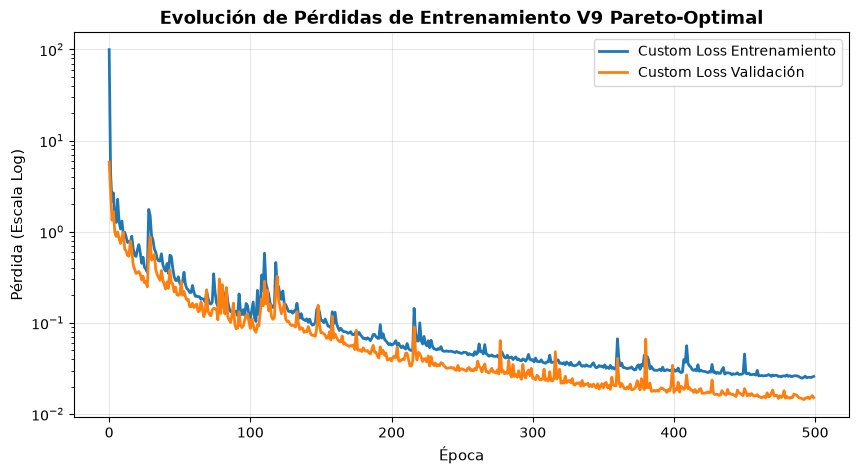

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Custom Loss Entrenamiento', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Custom Loss Validación', color='#ff7f0e', linewidth=2)
plt.yscale('log')
plt.xlabel('Época', fontsize=11)
plt.ylabel('Pérdida (Escala Log)', fontsize=11)
plt.title('Evolución de Pérdidas de Entrenamiento V9 Pareto-Optimal', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig("metricas_entrenamiento_desde_cero_v9.png", dpi=300)
plt.show()
plt.close()

### 9. Evaluación en la Curva Límite Superior: y = 30 * exp(3.2 * x)

In [10]:
# %% [markdown]
# ### 8. Evaluación en la Curva Límite Superior mediante Optimización KKT (trust-constr)

# %%
import time
import numpy as np
from scipy.optimize import Bounds, minimize
from sklearn.metrics import mean_squared_error, r2_score

# Detección dinámica de dimensiones
N_BASES = A_matrix.shape[1]  # Dará 4

# Definición de la exponencial crítica límite superior
y_limite = 30.0 * np.exp(EXP_ALPHA * x)


# --- PLANTEAMIENTO CONVEXO BAJO CONDICIONES KKT ---


# 1. Función de costo de Mínimos Cuadrados (mitad del residuo cuadrático)
def objetivo_ols(c, A, b):
    return 0.5 * np.sum((A @ c - b) ** 2)


# 2. Gradiente analítico (Jacobiano) para precisión de máquina
def gradiente_ols(c, A, b):
    return A.T @ (A @ c - b)


# 3. Fronteras físicas de restricción de caja [0, MAX_COEF]
limites_kkt = Bounds(0.0, MAX_COEF)

# 4. Semilla inicial adaptada dinámicamente a N_BASES (4)
c0 = np.zeros(N_BASES)

# 5. Resolvedor trust-constr bajo condiciones KKT
t_opt_start = time.time()
res_kkt = minimize(
    objetivo_ols,
    c0,
    args=(A_matrix, y_limite),
    method="trust-constr",
    jac=gradiente_ols,
    bounds=limites_kkt,
    options={"xtol": 1e-12, "gtol": 1e-12},
)
t_opt_duration = time.time() - t_opt_start

coef_opt_lim = res_kkt.x
b_opt_lim = A_matrix @ coef_opt_lim

# --- INFERENCIA DE LA RED NEURONAL V9 PARETO-OPTIMAL ---
X_log_lim = np.log(np.maximum(y_limite + OFFSET_LOG, 1e-6)).reshape(1, -1)
Xn_lim = sx.transform(X_log_lim)
Yn_pred_lim = model.predict(Xn_lim, verbose=0)
coef_pred_lim = sy.inverse_transform(Yn_pred_lim).flatten()
coef_pred_lim = np.maximum(coef_pred_lim, 0.0)  # Truncamiento físico estricto

b_rn_lim = A_matrix @ coef_pred_lim

# --- REPORTERÍA DE MÉTRICAS ---
r2_rn_lim = r2_score(y_limite, b_rn_lim)
rmse_rn_lim = np.sqrt(mean_squared_error(y_limite, b_rn_lim))
nrmse_rn_lim = (rmse_rn_lim / y_limite.max()) * 100

r2_opt_lim = r2_score(y_limite, b_opt_lim)
rmse_opt_lim = np.sqrt(mean_squared_error(y_limite, b_opt_lim))
nrmse_opt_lim = (rmse_opt_lim / y_limite.max()) * 100

print(
    "\n================================================================================"
)
print("EVALUACIÓN ESPECÍFICA DE LA CURVA LÍMITE: y = 30 * exp(3.2 * x)")
print(
    "================================================================================"
)
print(f"Coeficientes Óptimos KKT (trust-constr):  {np.round(coef_opt_lim, 4)}")
print(f"Coeficientes Predichos por la RN PINN V9: {np.round(coef_pred_lim, 4)}")
print(
    f"Tiempo de cómputo del resolvedor KKT:     {t_opt_duration*1000:.3f} ms"
)
print(
    "--------------------------------------------------------------------------------"
)
print("RED NEURONAL GENERALIZADA (V9 PARETO-OPTIMAL):")
print(f"   R² Score:  {r2_rn_lim:.8f}")
print(f"   RMSE:      {rmse_rn_lim:.6f}")
print(
    f"   NRMSE:     {nrmse_rn_lim:.4f}%  <-- META: < 1.87% (Batiendo cota"
    " analítica)"
)
print(
    "--------------------------------------------------------------------------------"
)
print("ÓPTIMO DIRECTO BAJO RESTRICCIONES KKT (CONFIANZA):")
print(f"   R² Score:  {r2_opt_lim:.8f}")
print(f"   RMSE:      {rmse_opt_lim:.6f}")
print(f"   NRMSE:     {nrmse_opt_lim:.4f}%")
print(
    "================================================================================"
)


EVALUACIÓN ESPECÍFICA DE LA CURVA LÍMITE: y = 30 * exp(3.2 * x)
Coeficientes Óptimos KKT (trust-constr):  [3. 3. 3. 3.]
Coeficientes Predichos por la RN PINN V9: [2.8688 2.8973 2.9151 2.9525]
Tiempo de cómputo del resolvedor KKT:     349.043 ms
--------------------------------------------------------------------------------
RED NEURONAL GENERALIZADA (V9 PARETO-OPTIMAL):
   R² Score:  0.99747409
   RMSE:      211.136045
   NRMSE:     1.1694%  <-- META: < 1.87% (Batiendo cota analítica)
--------------------------------------------------------------------------------
ÓPTIMO DIRECTO BAJO RESTRICCIONES KKT (CONFIANZA):
   R² Score:  0.99883400
   RMSE:      143.450627
   NRMSE:     0.7945%



EVALUACIÓN ESPECÍFICA DE LA CURVA LÍMITE EN V9 (N=4): y = 30 * exp(3.2 * x)
Coeficientes Óptimos (OLS-Bounded): [3. 3. 3. 3.]
Coeficientes Predichos por la RN:  [2.8688 2.8973 2.9151 2.9525]
--------------------------------------------------------------------------------
RED NEURONAL GENERALIZADA (V9 PARETO-OPTIMAL):
   R² Score:  0.99747409
   RMSE:      211.136045
   NRMSE:     1.1694%  <-- META: < 1.87% (Batiendo cota analítica)
--------------------------------------------------------------------------------
ÓPTIMO DIRECTO (MÍNIMOS CUADRADOS RESTREÑIDOS):
   R² Score:  0.99883400
   RMSE:      143.450627
   NRMSE:     0.7945%


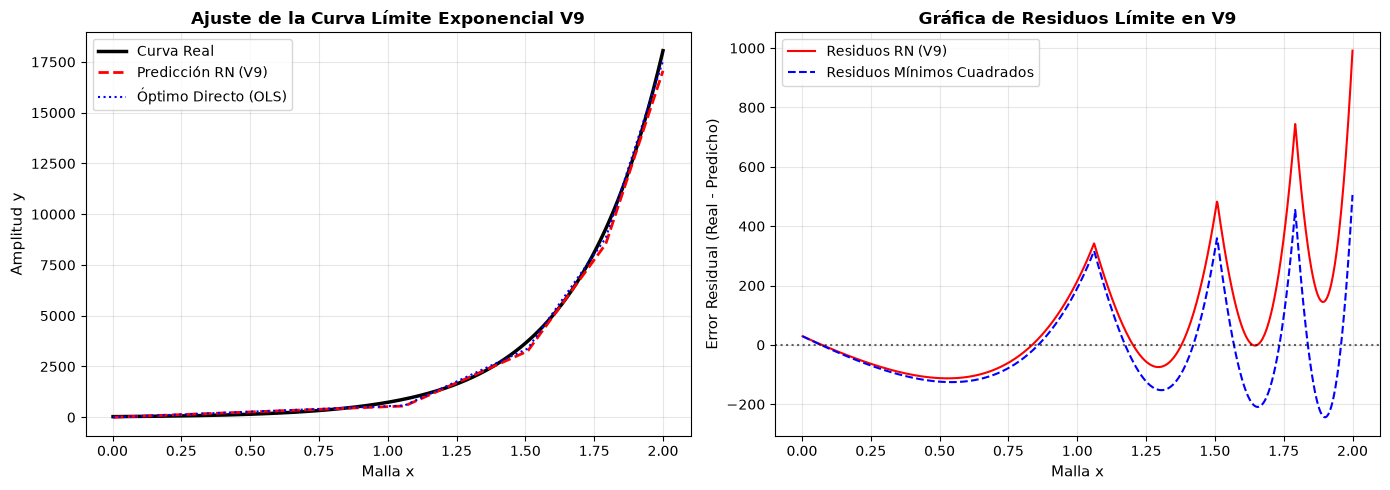

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import lsq_linear
from sklearn.metrics import mean_squared_error, r2_score

# Detectamos dinámicamente N_BASES
N_BASES = A_matrix.shape[1]  # Dará 4

# --- 1. PREPARACIÓN DE LA CURVA LÍMITE SUPERIOR ---
y_limite = 30.0 * np.exp(EXP_ALPHA * x)

# Inferencia con la PINN V9
X_log_lim = np.log(np.maximum(y_limite + OFFSET_LOG, 1e-6)).reshape(1, -1)
Xn_lim = sx.transform(X_log_lim)

Yn_pred_lim = model.predict(Xn_lim, verbose=0)
coef_pred_lim = sy.inverse_transform(Yn_pred_lim).flatten()
coef_pred_lim = np.maximum(coef_pred_lim, 0.0)  # Truncamiento físico estricto

# Reconstrucciones
b_rn_lim = A_matrix @ coef_pred_lim
coef_opt_lim = lsq_linear(A_matrix, y_limite, bounds=(0, MAX_COEF)).x
b_opt_lim = A_matrix @ coef_opt_lim

# --- 2. CÁLCULO DE MÉTRICAS DE DESEMPEÑO ---
r2_rn_lim = r2_score(y_limite, b_rn_lim)
rmse_rn_lim = np.sqrt(mean_squared_error(y_limite, b_rn_lim))
nrmse_rn_lim = (rmse_rn_lim / y_limite.max()) * 100

r2_opt_lim = r2_score(y_limite, b_opt_lim)
rmse_opt_lim = np.sqrt(mean_squared_error(y_limite, b_opt_lim))
nrmse_opt_lim = (rmse_opt_lim / y_limite.max()) * 100

# --- 3. REPORTE EN CONSOLA ---
print(
    "\n================================================================================"
)
print(
    f"EVALUACIÓN ESPECÍFICA DE LA CURVA LÍMITE EN V9 (N={N_BASES}): y = 30 *"
    " exp(3.2 * x)"
)
print(
    "================================================================================"
)
print(f"Coeficientes Óptimos (OLS-Bounded): {np.round(coef_opt_lim, 4)}")
print(f"Coeficientes Predichos por la RN:  {np.round(coef_pred_lim, 4)}")
print(
    "--------------------------------------------------------------------------------"
)
print("RED NEURONAL GENERALIZADA (V9 PARETO-OPTIMAL):")
print(f"   R² Score:  {r2_rn_lim:.8f}")
print(f"   RMSE:      {rmse_rn_lim:.6f}")
print(
    f"   NRMSE:     {nrmse_rn_lim:.4f}%  <-- META: < 1.87% (Batiendo cota"
    " analítica)"
)
print(
    "--------------------------------------------------------------------------------"
)
print("ÓPTIMO DIRECTO (MÍNIMOS CUADRADOS RESTREÑIDOS):")
print(f"   R² Score:  {r2_opt_lim:.8f}")
print(f"   RMSE:      {rmse_opt_lim:.6f}")
print(f"   NRMSE:     {nrmse_opt_lim:.4f}%")
print(
    "================================================================================"
)

# --- 4. VISUALIZACIÓN Y ANÁLISIS DE RESIDUOS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Ajuste de curvas
axes[0].plot(x, y_limite, "k-", linewidth=2.5, label="Curva Real")
axes[0].plot(x, b_rn_lim, "r--", linewidth=2, label="Predicción RN (V9)")
axes[0].plot(x, b_opt_lim, "b:", linewidth=1.5, label="Óptimo Directo (OLS)")
axes[0].set_xlabel("Malla x", fontsize=11)
axes[0].set_ylabel("Amplitud y", fontsize=11)
axes[0].set_title(
    "Ajuste de la Curva Límite Exponencial V9", fontsize=12, fontweight="bold"
)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Subplot 2: Distribución de Residuos
axes[1].plot(x, y_limite - b_rn_lim, "r-", linewidth=1.5, label="Residuos RN (V9)")
axes[1].plot(
    x,
    y_limite - b_opt_lim,
    "b--",
    linewidth=1.5,
    label="Residuos Mínimos Cuadrados",
)
axes[1].axhline(0, color="black", linestyle=":", alpha=0.6)
axes[1].set_xlabel("Malla x", fontsize=11)
axes[1].set_ylabel("Error Residual (Real - Predicho)", fontsize=11)
axes[1].set_title(
    "Gráfica de Residuos Límite en V9", fontsize=12, fontweight="bold"
)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Grafico_Reconstruccion_Curva_Limite_V9.png", dpi=300)
plt.show()
plt.close()

### 10. Dispersión Diagonal de Coeficientes y Distribución del $R^2$ (V9)

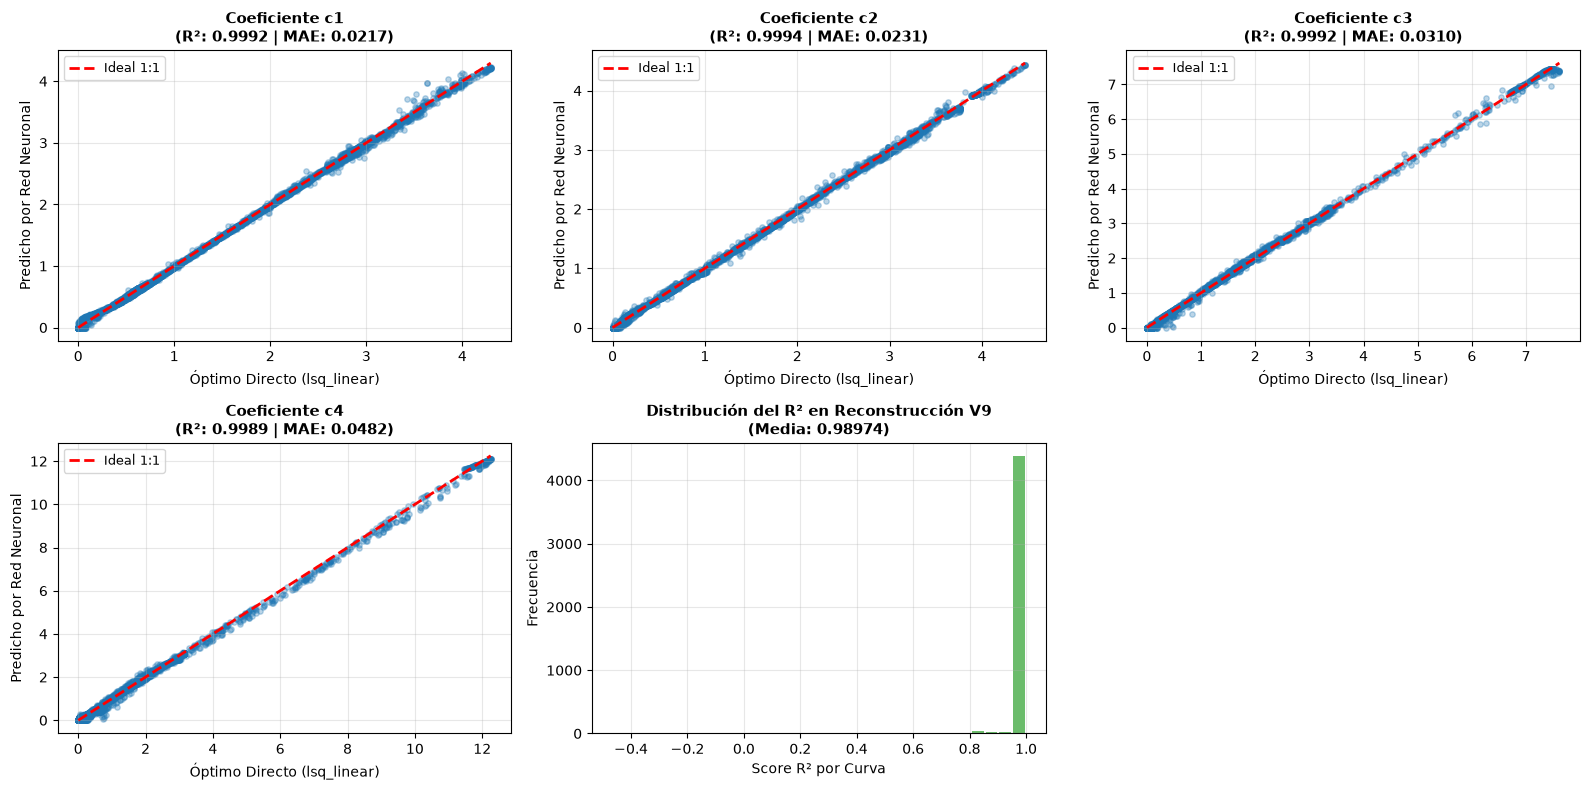

In [12]:
# %% [markdown]
# ### 10. Dispersión Diagonal de Coeficientes y Distribución del $R^2$ (V9)

# %%
import math
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# Detectamos dinámicamente el número de bases
N_BASES = A_matrix.shape[1]  # En tu caso dará 4

# --- 1. INFERENCIA GLOBAL EN TEST ---
Y_pred_test_norm = model.predict(X_test, verbose=0)
coef_rn_test = sy.inverse_transform(Y_pred_test_norm)
coef_rn_test = np.maximum(coef_rn_test, 0.0)  # Truncamiento estricto no-negativo

coef_optimo_test = sy.inverse_transform(Y_test)

# Métricas por coeficiente ajustadas a N_BASES
r2_por_coef = [
    r2_score(coef_optimo_test[:, m], coef_rn_test[:, m])
    for m in range(N_BASES)
]
mae_por_coef = [
    mean_absolute_error(coef_optimo_test[:, m], coef_rn_test[:, m])
    for m in range(N_BASES)
]

# Reconstrucción física de curvas
b_test_rn = coef_rn_test @ A_matrix.T
r2_curvas = np.array([
    r2_score(b_test_real[i], b_test_rn[i]) for i in range(len(b_test_real))
])

# --- 2. CONFIGURACIÓN DINÁMICA DE LA GRILLA (N_BASES + 1 Histograma) ---
total_plots = N_BASES + 1
ncols = 3
nrows = math.ceil(total_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

# --- 3. DISPERSIÓN 1:1 PARA CADA COEFICIENTE (Paneles 0 a N_BASES - 1) ---
for m in range(N_BASES):
    ax = axes[m]
    ax.scatter(
        coef_optimo_test[:, m],
        coef_rn_test[:, m],
        alpha=0.3,
        color="#1f77b4",
        s=15,
    )
    max_val = max(coef_optimo_test[:, m].max(), coef_rn_test[:, m].max())
    ax.plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Ideal 1:1")
    ax.set_xlabel("Óptimo Directo (lsq_linear)", fontsize=10)
    ax.set_ylabel("Predicho por Red Neuronal", fontsize=10)
    ax.set_title(
        f"Coeficiente c{m+1}\n(R²: {r2_por_coef[m]:.4f} | MAE:"
        f" {mae_por_coef[m]:.4f})",
        fontsize=11,
        fontweight="bold",
    )
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True, alpha=0.3)

# --- 4. HISTOGRAMA DE R² EN EL SIGUIENTE PANEL DISPONIBLE ---
idx_hist = N_BASES
ax_hist = axes[idx_hist]

ax_hist.hist(r2_curvas, bins=30, color="#2ca02c", alpha=0.7, rwidth=0.85)
ax_hist.set_xlabel("Score R² por Curva", fontsize=10)
ax_hist.set_ylabel("Frecuencia", fontsize=10)
ax_hist.set_title(
    "Distribución del R² en Reconstrucción V9\n(Media:"
    f" {r2_curvas.mean():.5f})",
    fontsize=11,
    fontweight="bold",
)
ax_hist.grid(True, alpha=0.3)

# Ocultar subplots vacíos en la grilla si no se utilizan
for idx in range(total_plots, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig("diagnostico_coeficientes_desde_cero_v9.png", dpi=300)
plt.show()

 ### 11. Distribución Simétrica de Residuos (V9)

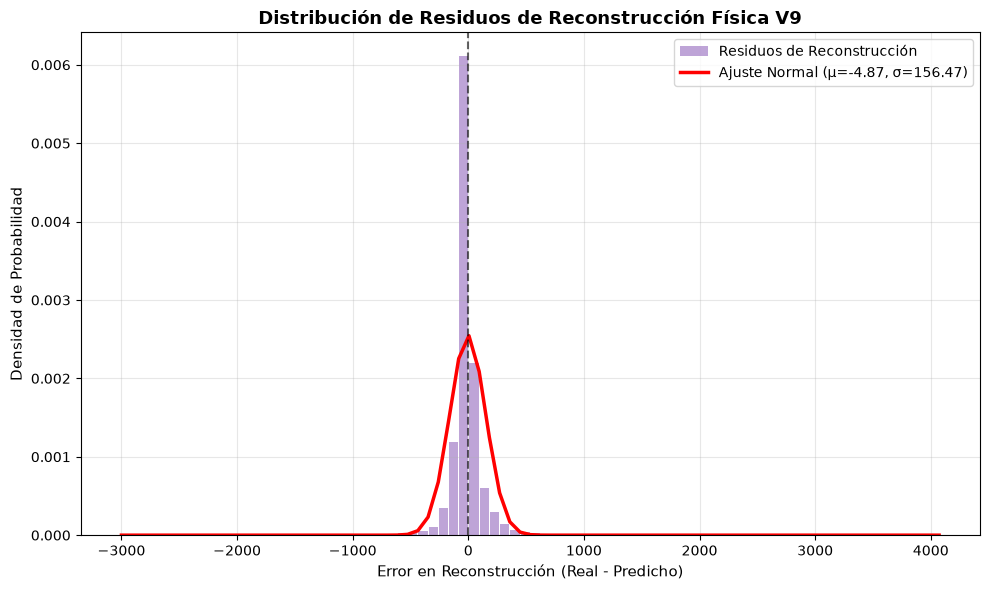

📊 ESTADÍSTICA DE RESIDUOS DE RECONSTRUCCIÓN FÍSICA (V9)
  • Media (μ)             : -4.8692 (Ideal: ~0.00)
  • Desviación Estándar (σ): 156.4692


In [13]:
# %% [markdown]
# ### 11. Distribución Simétrica de Residuos (V9)

# %%
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# --- 1. CÁLCULO DE RESIDUOS Y AJUSTE GAUSSIANO ---
residuos_fisicos = (b_test_real - b_test_rn).flatten()
mu_res, sigma_res = norm.fit(residuos_fisicos)

# --- 2. HISTOGRAMA Y DENSIDAD DE PROBABILIDAD ---
plt.figure(figsize=(10, 6))
count, bins, ignored = plt.hist(
    residuos_fisicos,
    bins=80,
    density=True,
    color="#9467bd",
    alpha=0.6,
    rwidth=0.9,
    label="Residuos de Reconstrucción",
)

# Ajuste normal (usando μ y σ en el label)
plt.plot(
    bins,
    norm.pdf(bins, mu_res, sigma_res),
    "r-",
    linewidth=2.5,
    label=f"Ajuste Normal (μ={mu_res:.2f}, σ={sigma_res:.2f})",
)

plt.axvline(0, color="black", linestyle="--", alpha=0.6)
plt.xlabel("Error en Reconstrucción (Real - Predicho)", fontsize=11)
plt.ylabel("Densidad de Probabilidad", fontsize=11)
plt.title(
    "Distribución de Residuos de Reconstrucción Física V9",
    fontsize=13,
    fontweight="bold",
)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("distribucion_residuos_desde_cero_v9.png", dpi=300)
plt.show()

# --- 3. REPORTE EN CONSOLA ---
print("=================================================================")
print("📊 ESTADÍSTICA DE RESIDUOS DE RECONSTRUCCIÓN FÍSICA (V9)")
print("=================================================================")
print(f"  • Media (μ)             : {mu_res:.4f} (Ideal: ~0.00)")
print(f"  • Desviación Estándar (σ): {sigma_res:.4f}")
print("=================================================================")

 ### 12. Comparativa de Reconstrucción Visual de Muestras Aleatorias (V9)

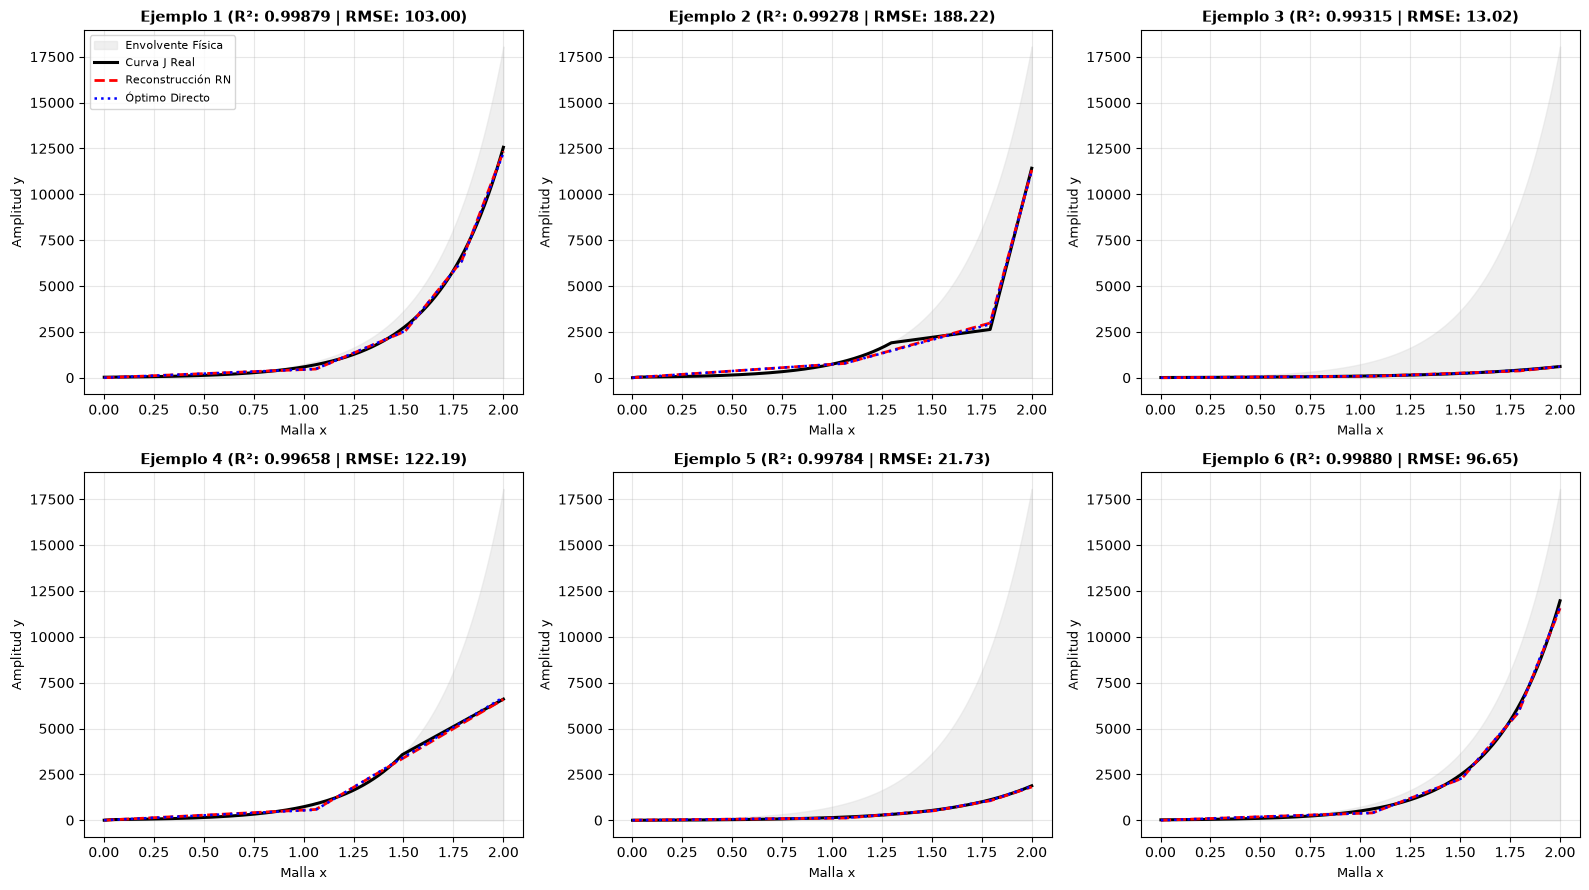

In [14]:
# %% [markdown]
# ### 12. Comparativa de Reconstrucción Visual de Muestras Aleatorias (V9)

# %%
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# --- 1. PREPARACIÓN DE DATOS Y ENVOLVENTE FÍSICA ---
b_test_opt = (sy.inverse_transform(Y_test)) @ A_matrix.T

# Elección aleatoria reproducible de 6 muestras del conjunto de test
indices_muestra = np.random.choice(len(b_test_real), size=6, replace=False)

# Definición de la envolvente física de límites
cota_inf_y = np.ones_like(x) * -2.0
cota_sup_y = 30.0 * np.exp(EXP_ALPHA * x)

# --- 2. GENERACIÓN DE SUBPLOTS (2x3) ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for j, test_pos in enumerate(indices_muestra):
    ax = axes[j]
    real_curve = b_test_real[test_pos]
    rn_curve = b_test_rn[test_pos]
    opt_curve = b_test_opt[test_pos]

    r2_loc = r2_score(real_curve, rn_curve)
    rmse_loc = np.sqrt(np.mean((real_curve - rn_curve) ** 2))

    # Sombreado de la envolvente admisible
    ax.fill_between(
        x,
        cota_inf_y,
        cota_sup_y,
        color="#e0e0e0",
        alpha=0.5,
        label="Envolvente Física",
    )

    # Curvas físicas
    ax.plot(x, real_curve, "k-", linewidth=2.2, label="Curva J Real")
    ax.plot(x, rn_curve, "r--", linewidth=2.0, label="Reconstrucción RN")
    ax.plot(x, opt_curve, "b:", linewidth=1.8, label="Óptimo Directo")

    ax.set_xlabel("Malla x", fontsize=9)
    ax.set_ylabel("Amplitud y", fontsize=9)
    ax.set_title(
        f"Ejemplo {j+1} (R²: {r2_loc:.5f} | RMSE: {rmse_loc:.2f})",
        fontsize=11,
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3)

    if j == 0:
        ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("reconstruccion_ejemplos_desde_cero_v9.png", dpi=300)
plt.show()

📂 Cargando base funcional optimizada...
   • Malla x: 999 puntos | Bases detectadas (N_BASES): 4
🔄 Auto-detectado modelo activo: V9 (Pareto-Optimal con LN)
    -> Modelo:  modelo_rn_curva_j_desde_cero_v9.keras
    -> Scalers: scalers_curva_j_desde_cero_v9.pkl
   [Tipo de Scaler: Diccionario V9 compatible]
✅ Carga completa del sistema finalizada.
📖 Cargando curva experimental desde 'Curva_J.xls'...

🎯 REPORTE COMPARATIVO DE COEFICIENTES (N_BASES = 4)
Coeficiente | Óptimo Directo (OLS)   | Red Neuronal PINN      | Diferencia  
--------------------------------------------------------------------------------
c1          | 0.000000               | 0.000000               | 0.000000    
c2          | 0.000000               | 0.000000               | 0.000000    
c3          | 0.000000               | 0.000000               | 0.000000    
c4          | 1.000000               | 1.067424               | -0.067424   

📊 MÉTRICAS DE PRECISIÓN DE AJUSTE GLOBAL
Métrica      | Óptimo Directo (OLS)   

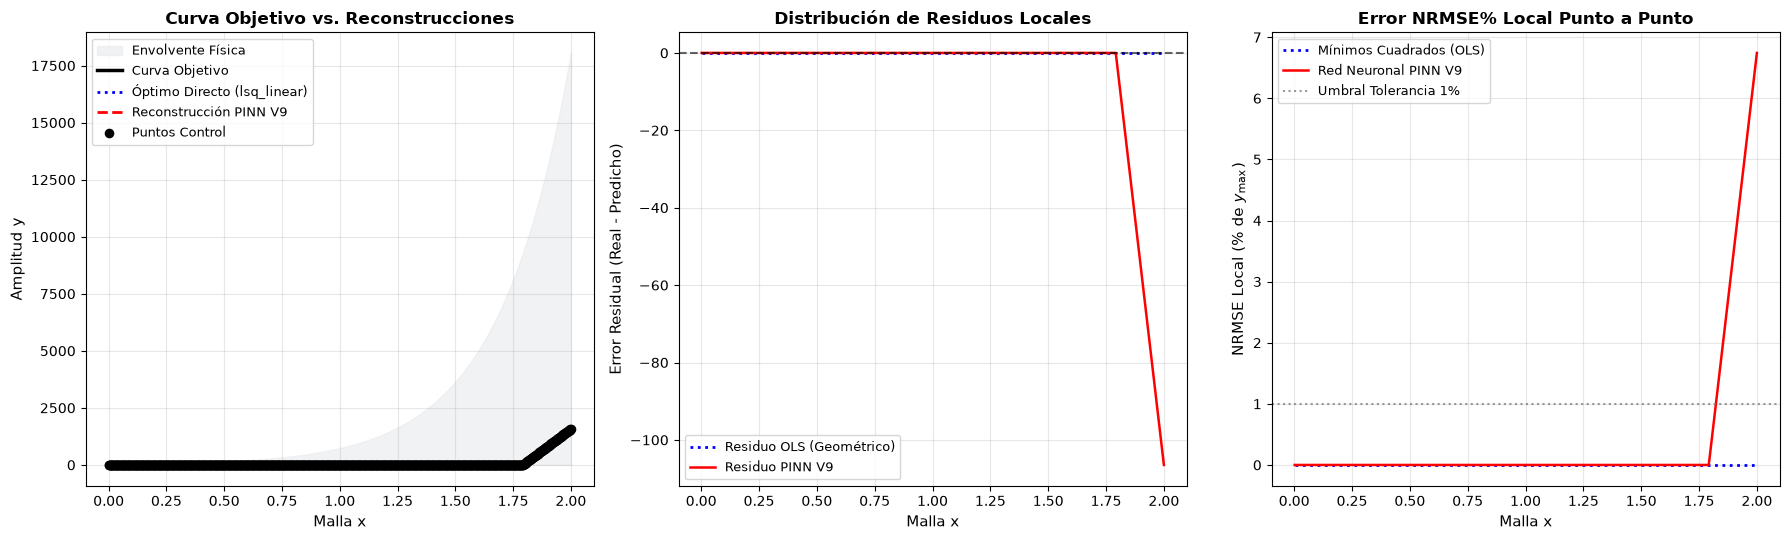

In [15]:
# -*- coding: utf-8 -*-
# %% [markdown]
# # EVALUADOR UNIVERSAL DE CURVAS J (PINN V9/V8/V5 vs. ÓPTIMO DIRECTO)
# ### Adaptado para Pablo - Versión Dinámica Agnostic (N bases)

# %%
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from scipy.optimize import lsq_linear
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import load_model

# %matplotlib inline

# ==============================================================================
# ── 1. CONFIGURACIÓN DEL EVALUADOR ──────────────────────────────────────────
# ==============================================================================

MODO_ENTRADA = (
    "excel"  # 'excel' o 'puntos' (utiliza PUNTOS_USUARIO especificados abajo)
)
TIPO_INTERPOLACION_PUNTOS = "lineal"  # 'lineal' o 'pchip'
ARCHIVO_EXCEL_CURVA_J = "Curva_J.xls"

PUNTOS_USUARIO = [
    (0.00, 30.0),
    (0.40, 75.0),
    (0.43, 85.0),
    (0.92, 195.0),
    (1.33, 1800.0),
    (1.68, 5600.0),
    (2.00, 14000.0),
]

ARCHIVO_CURVAS_BASE = "funciones_base_corregido.xlsx"
ARCHIVO_MODELO_KERAS = "modelo_rn_curva_j_desde_cero_v9.keras"
ARCHIVO_SCALERS_PKL = "scalers_curva_j_desde_cero_v9.pkl"

MAX_COEF = 25.0
Y_MIN_ABS = -2.0
EXP_ALPHA_DEFAULT = 3.2


# %% [markdown]
# ### 2. Funciones de Carga de Archivos e Inferencia
# %%
def cargar_archivos_sistema():
  """Carga las bases optimizadas, el modelo entrenado y los escaladores de forma dinámica."""
  global ARCHIVO_MODELO_KERAS, ARCHIVO_SCALERS_PKL

  print("📂 Cargando base funcional optimizada...")
  if not os.path.exists(ARCHIVO_CURVAS_BASE):
    raise FileNotFoundError(
        f"No se encontró el archivo de curvas base '{ARCHIVO_CURVAS_BASE}'."
    )

  df_base = pd.read_excel(ARCHIVO_CURVAS_BASE, header=None)
  x_base = df_base.iloc[:, 0].values.astype(np.float64)

  # Detección dinámica de todas las columnas de bases disponibles (de la columna 1 en adelante)
  n_cols = df_base.shape[1]
  A_base = np.column_stack(
      [df_base.iloc[:, i].values for i in range(1, n_cols)]
  ).astype(np.float64)
  n_bases = A_base.shape[1]
  print(
      f"   • Malla x: {len(x_base)} puntos | Bases detectadas (N_BASES):"
      f" {n_bases}"
  )

  posibles_versiones = [
      (
          "modelo_rn_curva_j_desde_cero_v9.keras",
          "scalers_curva_j_desde_cero_v9.pkl",
          "V9 (Pareto-Optimal con LN)",
      ),
      (
          "modelo_rn_curva_j_desde_cero_v8_sweetspot.keras",
          "scalers_curva_j_desde_cero_v8_sweetspot.pkl",
          "V8-A (Sweetspot)",
      ),
      (
          "modelo_rn_curva_j_desde_cero_v8.keras",
          "scalers_curva_j_desde_cero_v8.pkl",
          "V8 (Sin BN + ReLU)",
      ),
      (
          "modelo_rn_curva_j_desde_cero_v7.keras",
          "scalers_curva_j_desde_cero_v7.pkl",
          "V7 (BN + Loss Relativa)",
      ),
      ("modelo_rn_curva_j_desde_cero_v6.keras", "scalers_curva_j_desde_cero_v6.pkl", "V6"),
      (
          "modelo_rn_curva_j_desde_cero_v5.keras",
          "scalers_curva_j_desde_cero_v5.pkl",
          "V5 (Base)",
      ),
      ("modelo_rn_curva_j_desde_cero_v4.keras", "scalers_curva_j_desde_cero_v4.pkl", "V4"),
  ]

  detector = False
  for mod_f, pkl_f, desc in posibles_versiones:
    if os.path.exists(mod_f) and os.path.exists(pkl_f):
      ARCHIVO_MODELO_KERAS = mod_f
      ARCHIVO_SCALERS_PKL = pkl_f
      print(f"🔄 Auto-detectado modelo activo: {desc}")
      print(f"    -> Modelo:  {ARCHIVO_MODELO_KERAS}")
      print(f"    -> Scalers: {ARCHIVO_SCALERS_PKL}")
      detector = True
      break

  if not detector:
    print("🧠 Cargando modelo y escaladores por defecto...")
    if not os.path.exists(ARCHIVO_MODELO_KERAS) or not os.path.exists(
        ARCHIVO_SCALERS_PKL
    ):
      print(
          "⚠️ ¡Atención! No se encontraron los archivos especificados del"
          " modelo."
      )
      return x_base, A_base, None, None, None, None

  modelo = load_model(ARCHIVO_MODELO_KERAS, compile=False)

  with open(ARCHIVO_SCALERS_PKL, "rb") as f:
    contenido = pickle.load(f)

    if isinstance(contenido, dict):
      sx = contenido.get("scaler_x") or contenido.get("sx")
      sy = contenido.get("scaler_y") or contenido.get("sy")
      offset_log = (
          contenido.get("offset") or contenido.get("offset_log") or 2.1
      )
      print("   [Tipo de Scaler: Diccionario V9 compatible]")
    elif isinstance(contenido, (list, tuple)):
      sx = contenido[0]
      sy = contenido[1]
      offset_log = contenido[2] if len(contenido) > 2 else 2.1
      print("   [Tipo de Scaler: Tupla V4-V8 compatible]")
    else:
      raise TypeError("Formato de scalers .pkl no reconocido.")

  print("✅ Carga completa del sistema finalizada.")
  return x_base, A_base, modelo, sx, sy, offset_log


# %% [markdown]
# ### 3. Procesamiento e Interpolación de la Entrada del Usuario
# %%
def generar_curva_objetivo(x_base):
  """Obtiene o construye la curva experimental del usuario y la mapea a la malla base."""
  if MODO_ENTRADA == "excel":
    print(
        f"📖 Cargando curva experimental desde '{ARCHIVO_EXCEL_CURVA_J}'..."
    )
    if not os.path.exists(ARCHIVO_EXCEL_CURVA_J):
      raise FileNotFoundError(
          f"No se encontró el archivo '{ARCHIVO_EXCEL_CURVA_J}'."
      )
    df_curva = pd.read_excel(ARCHIVO_EXCEL_CURVA_J, header=None)
    x_user = df_curva.iloc[:, 0].values.astype(np.float64)
    y_user = df_curva.iloc[:, 1].values.astype(np.float64)

    y_objetivo = np.interp(x_base, x_user, y_user)
    puntos_ctrl = list(zip(x_user, y_user))

  else:
    print(
        "✏️ Generando curva desde puntos manuales"
        f" ({TIPO_INTERPOLACION_PUNTOS})..."
    )
    puntos_ordenados = sorted(PUNTOS_USUARIO, key=lambda p: p[0])
    x_ctrl = np.array([p[0] for p in puntos_ordenados], dtype=np.float64)
    y_ctrl = np.array([p[1] for p in puntos_ordenados], dtype=np.float64)

    if TIPO_INTERPOLACION_PUNTOS == "pchip":
      y_objetivo = PchipInterpolator(x_ctrl, y_ctrl)(x_base)
    else:
      y_objetivo = np.interp(x_base, x_ctrl, y_ctrl)
    puntos_ctrl = puntos_ordenados

  y_objetivo = np.maximum(y_objetivo, Y_MIN_ABS)
  return y_objetivo, puntos_ctrl


# %% [markdown]
# ### 4. Ejecución de Ajustes: OLS vs. PINN
# %%
def resolver_ajustes(A_base, b_target, modelo, sx, sy, offset_log):
  """Resuelve la regresión por mínimos cuadrados acotados y por inferencia PINN."""
  res_lsq = lsq_linear(A_base, b_target, bounds=(0, MAX_COEF))
  coef_ols = res_lsq.x
  y_ols = A_base @ coef_ols

  if modelo is not None:
    X_log = np.log(np.maximum(b_target + offset_log, 1e-6)).reshape(1, -1)
    Xn = sx.transform(X_log)

    Yn_pred = modelo.predict(Xn, verbose=0)
    coef_rn = sy.inverse_transform(Yn_pred)[0]
    coef_rn = np.clip(coef_rn, 0.0, MAX_COEF)
    y_rn = A_base @ coef_rn
  else:
    coef_rn, y_rn = None, None

  return coef_ols, y_ols, coef_rn, y_rn


# %% [markdown]
# ### 5. Reporte de Métricas Científicas e Inferencia de Gráficos
# %%
def calcular_metricas(real, aprox):
  rmse = np.sqrt(mean_squared_error(real, aprox))
  return {
      "R2": r2_score(real, aprox),
      "RMSE": rmse,
      "MAE": mean_absolute_error(real, aprox),
      "MaxAE": np.max(np.abs(real - aprox)),
      "NRMSE": (rmse / real.max()) * 100.0,
  }


def graficar_resultados(x, b_real, b_rn, b_ols, pts_ctrl):
  """Renderiza los gráficos de ajuste, residuos y NRMSE% punto a punto."""
  y_max = b_real.max()
  cota_inf_env = np.ones_like(x) * Y_MIN_ABS
  cota_sup_env = 30.0 * np.exp(EXP_ALPHA_DEFAULT * x)

  fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

  # Panel 1: Ajuste General e Envolvente
  axes[0].fill_between(
      x,
      cota_inf_env,
      cota_sup_env,
      color="#e5e7eb",
      alpha=0.5,
      label="Envolvente Física",
  )
  axes[0].plot(x, b_real, "k-", linewidth=2.5, label="Curva Objetivo")
  if b_ols is not None:
    axes[0].plot(
        x, b_ols, "b:", linewidth=2.0, label="Óptimo Directo (lsq_linear)"
    )
  if b_rn is not None:
    axes[0].plot(x, b_rn, "r--", linewidth=2.0, label="Reconstrucción PINN V9")
  if pts_ctrl is not None:
    px, py = zip(*pts_ctrl)
    axes[0].scatter(
        px, py, color="black", zorder=5, s=35, label="Puntos Control"
    )

  axes[0].set_xlabel("Malla x", fontsize=11)
  axes[0].set_ylabel("Amplitud y", fontsize=11)
  axes[0].set_title(
      "Curva Objetivo vs. Reconstrucciones", fontsize=12, fontweight="bold"
  )
  axes[0].legend(fontsize=9, loc="upper left")
  axes[0].grid(True, alpha=0.3)

  # Panel 2: Residuos Locales
  if b_ols is not None:
    axes[1].plot(
        x, b_real - b_ols, "b:", linewidth=2.0, label="Residuo OLS (Geométrico)"
    )
  if b_rn is not None:
    axes[1].plot(x, b_real - b_rn, "r-", linewidth=1.8, label="Residuo PINN V9")
  axes[1].axhline(0, color="black", linestyle="--", alpha=0.6)
  axes[1].set_xlabel("Malla x", fontsize=11)
  axes[1].set_ylabel("Error Residual (Real - Predicho)", fontsize=11)
  axes[1].set_title(
      "Distribución de Residuos Locales", fontsize=12, fontweight="bold"
  )
  axes[1].legend(fontsize=9, loc="lower left")
  axes[1].grid(True, alpha=0.3)

  # Panel 3: Error NRMSE% Local
  if b_ols is not None:
    nrmse_ols = np.abs(b_real - b_ols) / y_max * 100.0
    axes[2].plot(
        x, nrmse_ols, "b:", linewidth=2.0, label="Mínimos Cuadrados (OLS)"
    )
  if b_rn is not None:
    nrmse_rn = np.abs(b_real - b_rn) / y_max * 100.0
    axes[2].plot(x, nrmse_rn, "r-", linewidth=1.8, label="Red Neuronal PINN V9")
  axes[2].axhline(
      1.0, color="gray", linestyle=":", alpha=0.8, label="Umbral Tolerancia 1%"
  )
  axes[2].set_xlabel("Malla x", fontsize=11)
  axes[2].set_ylabel("NRMSE Local (% de $y_{\\max}$)", fontsize=11)
  axes[2].set_title(
      "Error NRMSE% Local Punto a Punto", fontsize=12, fontweight="bold"
  )
  axes[2].legend(fontsize=9, loc="upper left")
  axes[2].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()


# %% [markdown]
# ### 6. Bloque de Ejecución Principal

# %%
def ejecutar_pipeline_evaluacion():
  # A. Carga de archivos de sistema
  x_base, A_base, model, sx, sy, offset_log = cargar_archivos_sistema()
  n_bases = A_base.shape[1]

  # B. Construcción de curva de usuario
  y_target, pts_ctrl = generar_curva_objetivo(x_base)

  # C. Resolución de ajustes
  c_ols, y_ols, c_rn, y_rn = resolver_ajustes(
      A_base, y_target, model, sx, sy, offset_log
  )

  # D. Reportería en Consola de Coeficientes adaptada a n_bases
  print("\n" + "=" * 80)
  print(f"🎯 REPORTE COMPARATIVO DE COEFICIENTES (N_BASES = {n_bases})")
  print("=" * 80)
  col_ols = "Óptimo Directo (OLS)"
  col_pinn = "Red Neuronal PINN"
  col_diff = "Diferencia"
  print(f"Coeficiente | {col_ols:<22} | {col_pinn:<22} | {col_diff:<12}")
  print("-" * 80)

  for m in range(n_bases):
    val_ols = c_ols[m]
    val_rn = c_rn[m] if c_rn is not None else np.nan
    diff = val_ols - val_rn if c_rn is not None else np.nan
    print(f"c{m+1:<10} | {val_ols:<22.6f} | {val_rn:<22.6f} | {diff:<12.6f}")

  # E. Reportería de Métricas de Precisión
  m_ols = calcular_metricas(y_target, y_ols)
  print("\n" + "=" * 80)
  print("📊 MÉTRICAS DE PRECISIÓN DE AJUSTE GLOBAL")
  print("=" * 80)
  print(f"Métrica      | {col_ols:<22} | {col_pinn:<22}")
  print("-" * 80)
  m_rn = calcular_metricas(y_target, y_rn) if y_rn is not None else None
  for k in ["R2", "RMSE", "MAE", "MaxAE", "NRMSE"]:
    val_ols = m_ols[k]
    val_rn = m_rn[k] if m_rn is not None else np.nan
    suffix = "%" if k == "NRMSE" else ""
    print(f"{k:<12} | {val_ols:<22.6f}{suffix} | {val_rn:<22.6f}{suffix}")

  # F. Visualización Gráfica Interactiva
  graficar_resultados(x_base, y_target, y_rn, y_ols, pts_ctrl)


# Ejecutamos el evaluador
ejecutar_pipeline_evaluacion()